# UNIVERSIDAD DE ORIENTE
## Facultad de Ingeniería y Arquitectura  
### Machine Learning – Actividad Práctica Cómputo 1  

**Estudiante:** Jimenez Arias  
**Carnet:** U20231085

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import trim_mean

np.random.seed(20231085)


# EJERCICIO 1

Según mi carnet:
- α = 8  
- θ = 5  

Media poblacional: μ = αθ = 40  
Varianza poblacional: Var = αθ² = 200  


In [20]:
alpha = 8
theta = 5

muestra_10 = np.random.gamma(alpha, theta, 10)
muestra_1000 = np.random.gamma(alpha, theta, 1000)
muestra_10000 = np.random.gamma(alpha, theta, 10000)


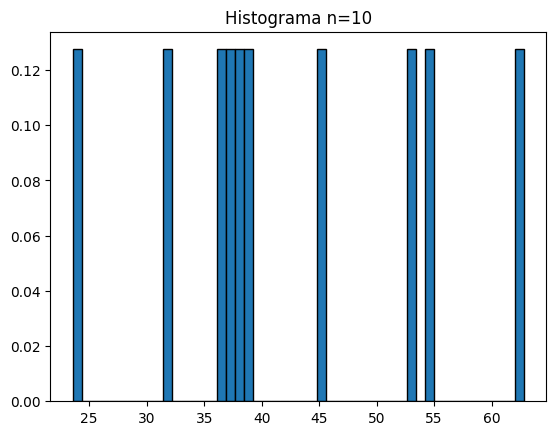

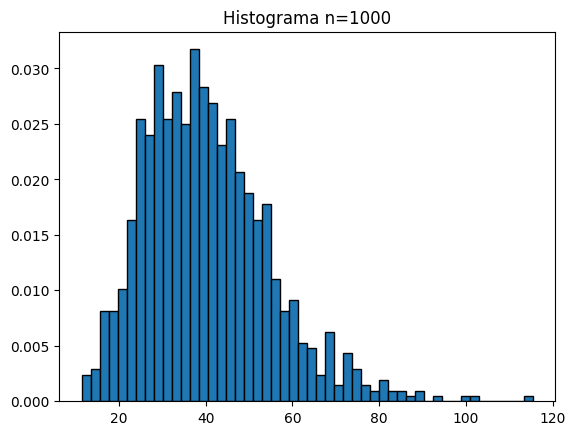

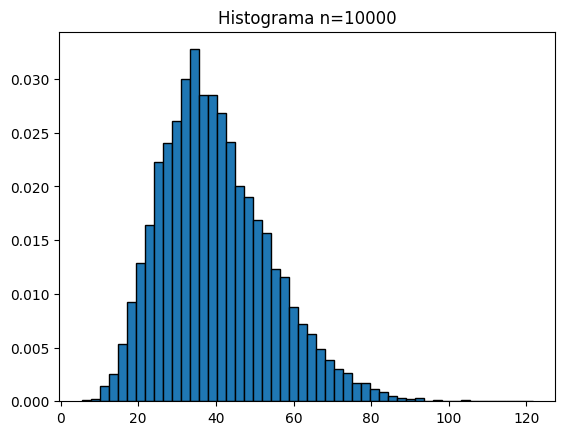

In [21]:
for muestra, n in [(muestra_10,10),(muestra_1000,1000),(muestra_10000,10000)]:
    plt.hist(muestra, bins=50, edgecolor="black", density=True)
    plt.title(f"Histograma n={n}")
    plt.show()

In [22]:
for muestra, n in [(muestra_10,10),(muestra_1000,1000),(muestra_10000,10000)]:
    print(f"n={n}")
    print("Media:", np.mean(muestra))
    print("Varianza:", np.var(muestra))
    print()


n=10
Media: 42.1653475116046
Varianza: 124.70772596083141

n=1000
Media: 40.347394319348034
Varianza: 208.56241609374928

n=10000
Media: 40.02497902391651
Varianza: 198.1154677599795



### Interpretación

Cuando n=10 los resultados varían bastante respecto a los valores teóricos (40 y 200).  
Al aumentar el tamaño de muestra, los valores se acercan mucho más a los parámetros poblacionales.  
Esto es consistente con lo visto en clase sobre cómo el estimador mejora cuando aumenta n.



### Lo que yo entendí:

Mientras más grande es la muestra, más parecido es el resultado a la población real.  
Con muestras pequeñas puede haber bastante variación, pero al aumentar n la estimación se estabiliza.



# EJERCICIO 2


In [23]:
n = 55
muestra = np.random.normal(40, 8, 55)

X = np.mean(muestra)
S = np.std(muestra)

# Reemplazo del primer valor por el valor atípico
muestra[0] = X + 4*S

In [24]:
media_10 = trim_mean(muestra, 0.10)
media_15 = trim_mean(muestra, 0.15)

Q1 = np.percentile(muestra, 25)
Q3 = np.percentile(muestra, 75)
centrimedia = (Q1 + Q3) / 2

print("Media recortada 10%:", media_10)
print("Media recortada 15%:", media_15)
print("Centrimedia:", centrimedia)

Media recortada 10%: 40.87331670719925
Media recortada 15%: 40.66311984172926
Centrimedia: 39.81493945256842


In [25]:
winsor = stats.mstats.winsorize(muestra, limits=0.15)
print("Media winsorizada 15%:", np.mean(winsor))

Media winsorizada 15%: 40.74028741339185


In [26]:
mediana = np.median(muestra)
trimedia = (Q1 + 2*mediana + Q3)/4

print("Trimedia:", trimedia)
print("Media muestral:", np.mean(muestra))

Trimedia: 40.537540085019096
Media muestral: 41.87993945210605


In [27]:
mad = stats.median_abs_deviation(muestra)
desv_tipica = np.std(muestra)
print("MAD:", mad)
print("Desviación estándar:", desv_tipica)

MAD: 6.703843970443842
Desviación estándar: 9.339077265029813



### Interpretación

La media muestral cambia bastante debido al valor atípico.  
En cambio, las medias recortadas, la winsorizada y la trimedia son más estables.  
El MAD también se ve menos afectado que la desviación estándar, lo cual confirma lo visto en estadística robusta.



### Lo que yo entendí:

Cuando hay un valor extremo, la media normal y la desviación estándar se alteran mucho.  
Las medidas robustas funcionan mejor porque eliminan o reducen el impacto de esos valores raros.



# EJERCICIO 3

Parámetros:
- α = 1 (se ajusta porque Beta no admite 0)
- β = 8
- λ = 5


In [28]:
alpha = 1
beta = 8
lam = 5

x = np.random.exponential(1/lam, 300)
Y = np.random.beta(alpha, beta, 300)
epsilon = 2*Y - 1

y1 = 5 + 2*x + np.sqrt(x)*epsilon
y2 = 5 + 2*x + epsilon
y3 = 5 + 2*x + epsilon/(1+np.abs(x))


In [29]:
X_reg = sm.add_constant(x)

modelo1 = sm.OLS(y1, X_reg).fit()
modelo2 = sm.OLS(y2, X_reg).fit()
modelo3 = sm.OLS(y3, X_reg).fit()

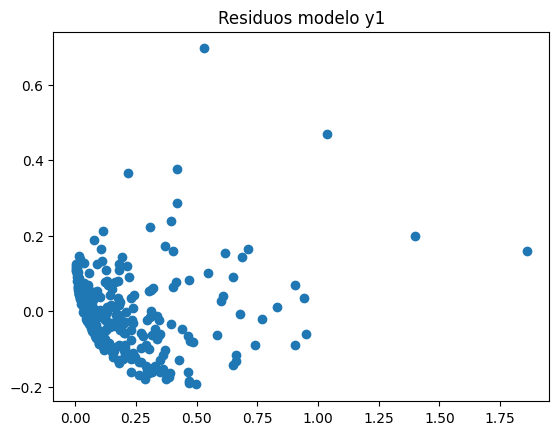

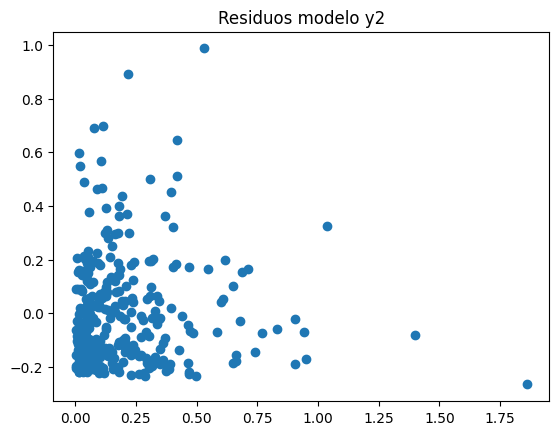

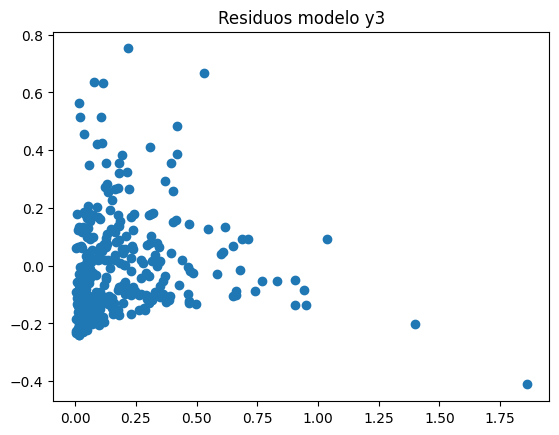

In [30]:
for modelo, nombre in [(modelo1,"y1"),(modelo2,"y2"),(modelo3,"y3")]:
    plt.scatter(x, modelo.resid)
    plt.title(f"Residuos modelo {nombre}")
    plt.show()

In [31]:
print("Breusch-Pagan y1:", het_breuschpagan(modelo1.resid, modelo1.model.exog))
print("Breusch-Pagan y2:", het_breuschpagan(modelo2.resid, modelo2.model.exog))
print("Breusch-Pagan y3:", het_breuschpagan(modelo3.resid, modelo3.model.exog))

Breusch-Pagan y1: (np.float64(22.303235462002323), np.float64(2.3281401414363224e-06), np.float64(23.93389126709561), np.float64(1.6344297877113039e-06))
Breusch-Pagan y2: (np.float64(0.8275279907665634), np.float64(0.3629883115714475), np.float64(0.824284866827013), np.float64(0.36466395076185876))
Breusch-Pagan y3: (np.float64(0.023469952363142088), np.float64(0.8782412979602144), np.float64(0.023315310044761103), np.float64(0.8787433081618943))



### Interpretación

En y1 se observa que la dispersión de los residuos aumenta con x, por lo que hay heterocedasticidad.  
En y2 los residuos mantienen una dispersión más uniforme, indicando homocedasticidad.  
En y3 se observa una ligera variación en la varianza, aunque menos marcada que en y1.



### Lo que yo entendí:

Si la nube de residuos se abre o cambia de tamaño, hay heterocedasticidad.  
Si se mantiene más o menos igual en todo el rango, entonces es homocedástico.  
La prueba de Breusch-Pagan confirma lo que se ve en el gráfico.
